<center><b>EE (P) 533 Spring 2026<br>
Analog Circuits for Sensor Systems<br>
University of Washington Electrical & Computer Engineering</b></center>


<b>Instructor: Mahmood Hameed<br>
Assignment #2 (10 points)<br>
Due Monday, April 20 (Submit on Canvas as a Jupyter Notebook)</b> 

*Please show your work*

<b>Problem 1: Common-emitter amplifier, small-signal analysis

<center><img src="HW2_common_emitter.png" width=400></center>

The common-emitter amplifier can be used to achieve high levels of voltage gain in analog circuits. However, gain can be affected by loading at both at the input and output of the amplifier, so we need to ensure that minimal loading occurs when the amplifier is connected to a sensor or other circuit blocks. In addition, the bandwidth over which the maximum gain can be achieved is limitied by the presence of capacitance, which results in loading at higher frequencies (away from DC).

For the following, $T = 27C$, $R_C = 1k\Omega$, $V_S (DC) = 0.69V$, $V_{CC} = 5V$, and $C_L = 100nF$

Use the NXP 2N3904 $npn$ transistor ($V_A = 100V$, $\beta = 300$, $I_S = 10^{-14}$) for your analysis and simulations.

<u>*Analysis*</u>

__a)__ Sketch the small-signal model and determine an expression for the the transfer function $\dfrac{V_{out}}{V_s}(s)$ in terms of $g_m$, $R_C$, $r_o$, and $C_{L}$. Assume no DC loading (i.e. $R_S \rightarrow 0$ and $R_L \rightarrow \infty$).

With $R_S \rightarrow 0$, $v_\pi = v_s$. Replacing the BJT with its small-signal model gives this circuit (base node on the left with $r_\pi$, collector node on the right with $g_m v_\pi$, $r_o$, $R_C$, and $C_L$ all in parallel to AC ground, since $V_{CC}$ is AC ground):

<center>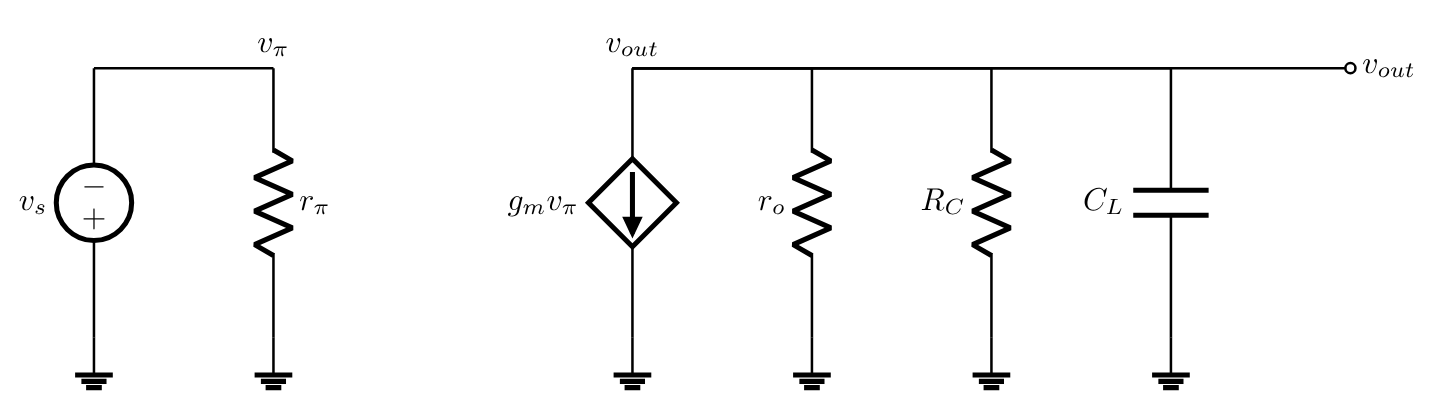</center>

At the output node, the dependent source pulls current $g_m v_\pi = g_m v_s$. The impedance from $v_{out}$ to ground is $R_C \| r_o \| \frac{1}{sC_L}$, so

$$
\frac{V_{out}}{V_s}(s) = -g_m \left(R_C \,\|\, r_o \,\|\, \frac{1}{sC_L}\right) = -\frac{g_m (R_C \| r_o)}{1 + s (R_C \| r_o) C_L}
$$


__b)__ Calculate the DC gain, input resistance, output resistance, and 3dB bandwidth of the amplifier (again, assuming no loading) using the component and parameter values provided. Plot the frequency response (magnitude and phase) of $\dfrac{V_{out}}{V_s}(s)$.

$V_T = kT/q \approx 25.85$mV at 27°C. From the BJT:

$$I_C = I_S e^{V_{BE}/V_T}, \qquad g_m = \frac{I_C}{V_T}, \qquad r_\pi = \frac{\beta}{g_m}, \qquad r_o = \frac{V_A}{I_C}$$

And from the transfer function in part (a):
- DC gain: $A_v(0) = -g_m(R_C \| r_o)$
- Input resistance: $r_\pi$
- Output resistance: $R_C \| r_o$
- 3dB bandwidth: $f_{3dB} = \frac{1}{2\pi (R_C \| r_o) C_L}$


I_C=3.9118893098964627 mA
g_m=0.1513303408083738 S
r_pi=1982.418055741269 ohm
r_o=25563.095496341317 ohm
R_out=R_C||r_o=962.3537851551324 ohm
DC gain A_v=-145.63332628575472 V/V
DC gain=43.265215379465154 dB
w_3dB=10391.188930989647 rad/s
f_3dB=1653.80908296879 Hz


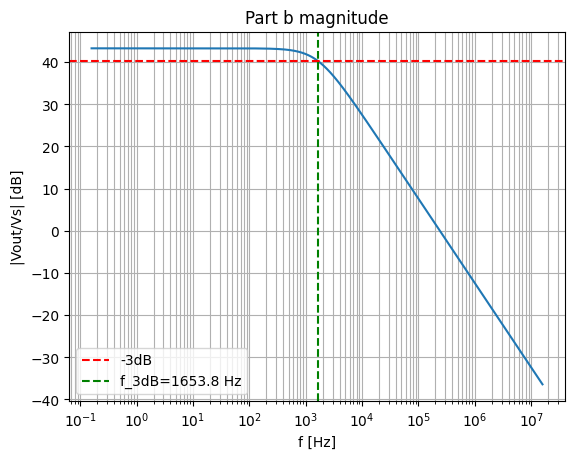

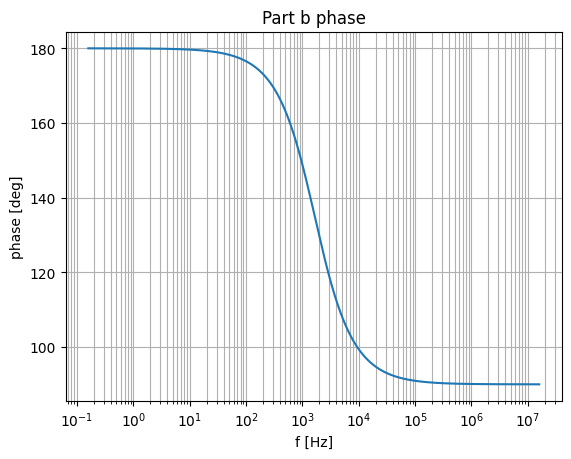

In [1]:
import numpy as np
import matplotlib.pyplot as plt

V_T=25.85e-3
I_S=1e-14
V_BE=0.69
beta=300
V_A=100
R_C=1e3
C_L=100e-9

I_C=I_S*np.exp(V_BE/V_T)
g_m=I_C/V_T
r_pi=beta/g_m
r_o=V_A/I_C
R_out=(R_C*r_o)/(R_C+r_o)
A_v=-g_m*R_out
A_v_dB=20*np.log10(abs(A_v))
w_3dB=1/(R_out*C_L)
f_3dB=w_3dB/(2*np.pi)

print(f'I_C={I_C*1e3} mA')
print(f'g_m={g_m} S')
print(f'r_pi={r_pi} ohm')
print(f'r_o={r_o} ohm')
print(f'R_out=R_C||r_o={R_out} ohm')
print(f'DC gain A_v={A_v} V/V')
print(f'DC gain={A_v_dB} dB')
print(f'w_3dB={w_3dB} rad/s')
print(f'f_3dB={f_3dB} Hz')

w=np.logspace(0,8,2001)
s=1j*w
H=-g_m*R_out/(1+s*R_out*C_L)
mag=20*np.log10(np.abs(H))
phase=np.angle(H,deg=True)

plt.figure()
plt.semilogx(w/(2*np.pi),mag)
plt.xlabel('f [Hz]')
plt.ylabel('|Vout/Vs| [dB]')
plt.title('Part b magnitude')
plt.grid(True,which='both')
plt.axhline(A_v_dB-3,color='r',linestyle='--',label='-3dB')
plt.axvline(f_3dB,color='g',linestyle='--',label=f'f_3dB={f_3dB:.1f} Hz')
plt.legend()
plt.show()

plt.figure()
plt.semilogx(w/(2*np.pi),phase)
plt.xlabel('f [Hz]')
plt.ylabel('phase [deg]')
plt.title('Part b phase')
plt.grid(True,which='both')
plt.show()


<u>*Simulation/Design*</u>

__c)__ Simulate the DC operating point (.op analysis) of the circuit in SPICE (still no loading, $R_S \rightarrow 0$ and $R_L \rightarrow \infty$). Provide a screen capture of your circuit with all DC operating points labeled (right-click on the net and select *Place .op Data Label*).

Perform an AC simulation of the circuit and plot the frequency reponse. Indicate both the gain at $f = 10Hz$ and the 3dB bandwidth on the magnitude plot. 

Perform a transient analysis of the circuit to verify the gain. Use a sinusoidal voltage as an input signal with an amplitude of $500 \mu V$, frequency of $10 Hz$, and DC offset of $0.69V$. Show that the peak-to-peak amplitude of the output agrees with your calculation from Part b and your AC analysis result.

I simulated the nominal circuit in LTspice (netlist `ce_nominal.cir` for `.op`+`.ac`, `ce_nominal_tran.cir` for `.tran` since LTspice only runs one analysis at a time).

**.op operating point** (from SPICE Error Log, Ctrl+L):

<center>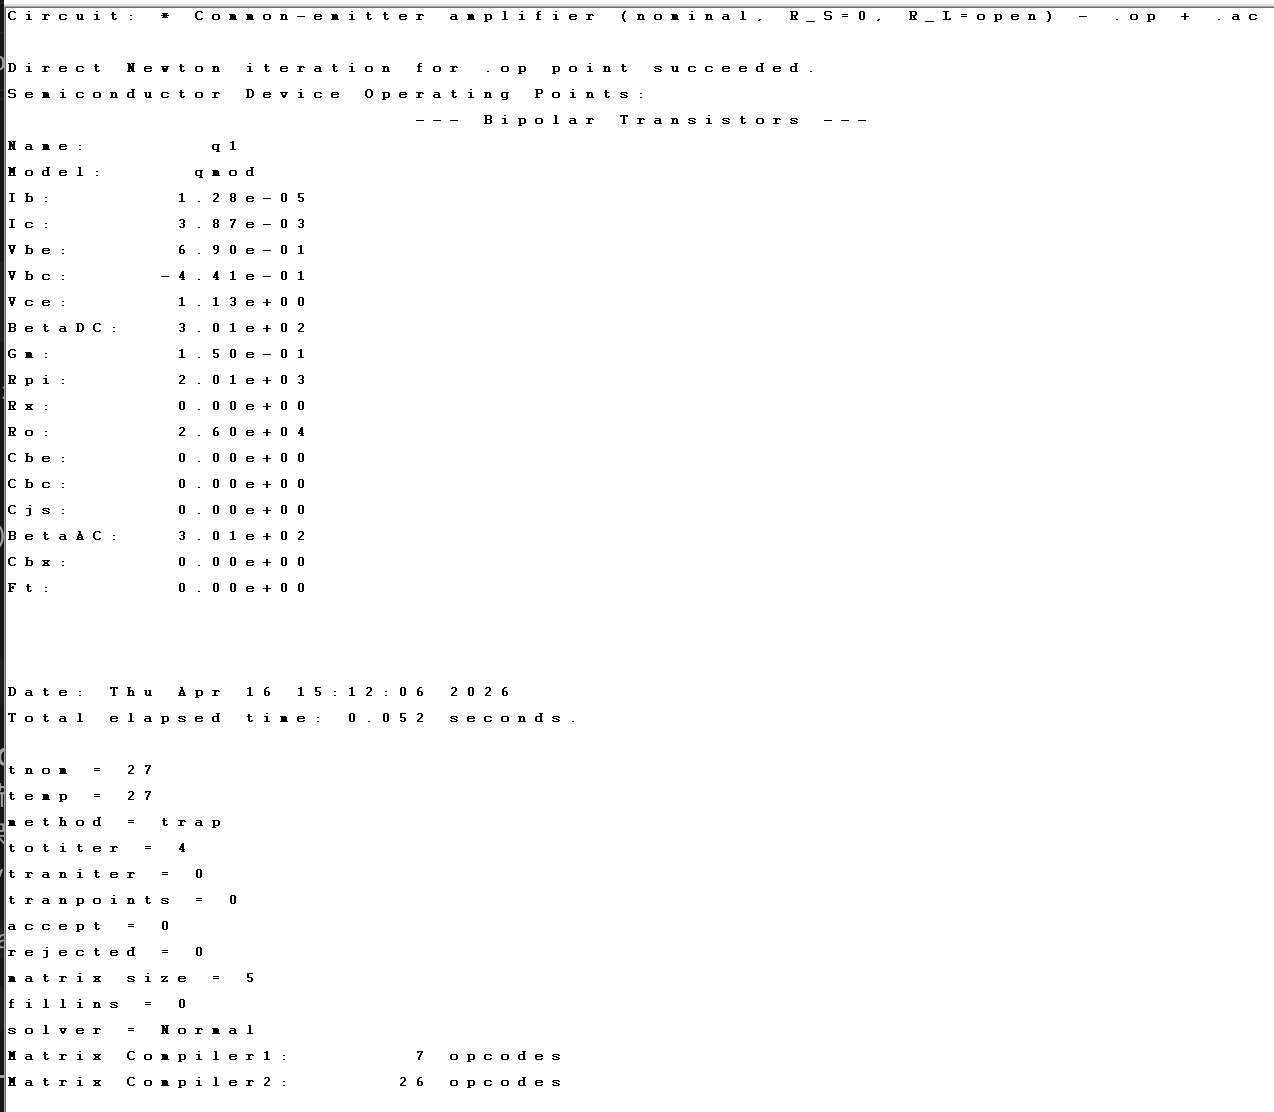</center>

$I_C \approx 3.87$mA, $g_m \approx 0.150$S, $r_\pi \approx 2.01$k$\Omega$, $r_o \approx 26$k$\Omega$, $V_{ce} \approx 1.13$V. $V_B = 0.69$V, $V_E = 0$V (grounded), $V_C = V_B - V_{bc} = 0.69 - (-0.441) = 1.13$V. These match part b.

**AC magnitude + phase**:

<center>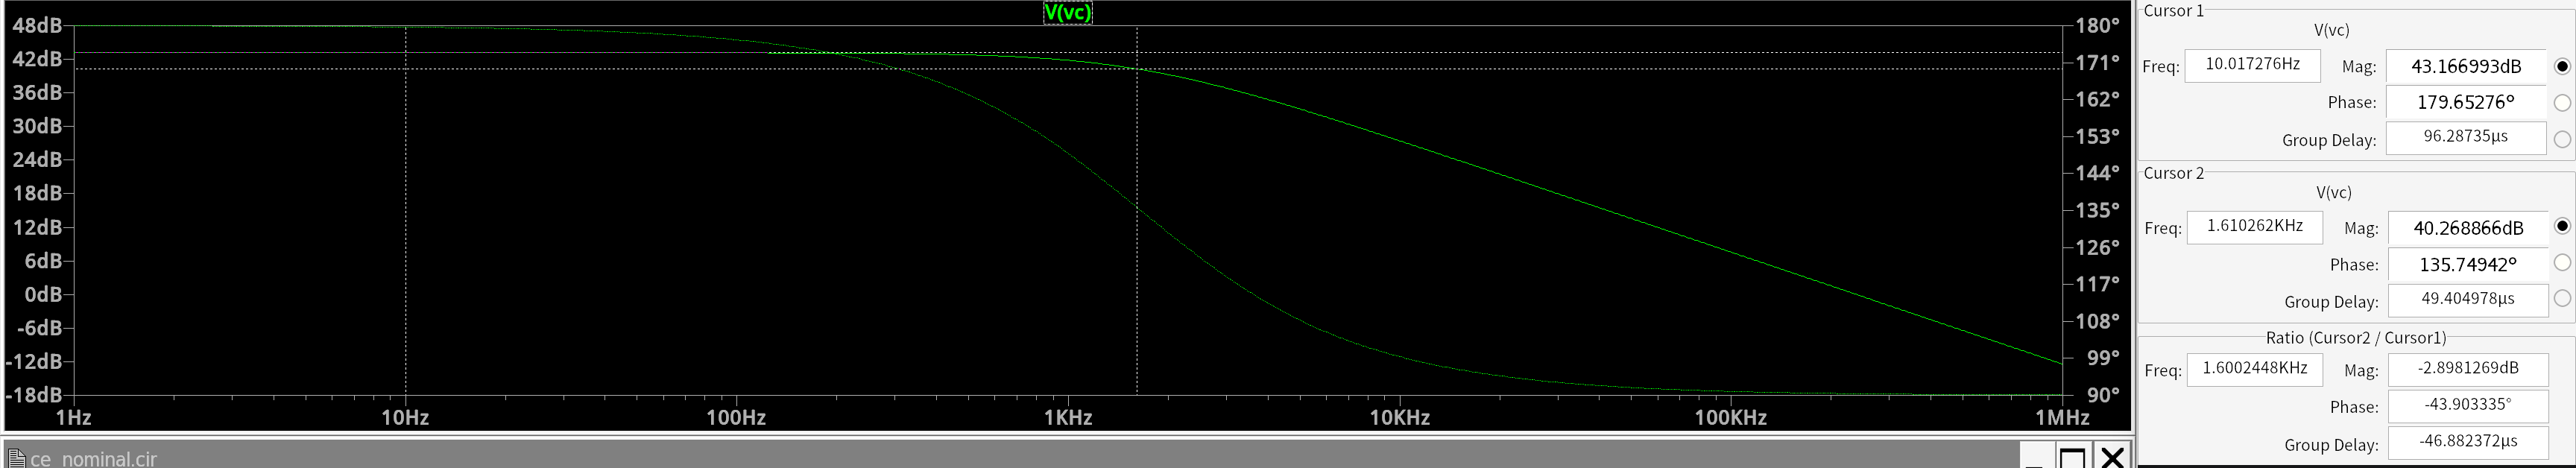</center>

Cursor 1 at 10Hz gives 43.17 dB. Cursor 2 at 1.61kHz gives 40.27 dB, which is -2.9 dB relative to cursor 1 (the 3dB corner). So $f_{3dB} \approx 1.6$kHz, also matches part b.

**Transient** (500$\mu$V sine at 10Hz on top of 0.69V DC):

<center>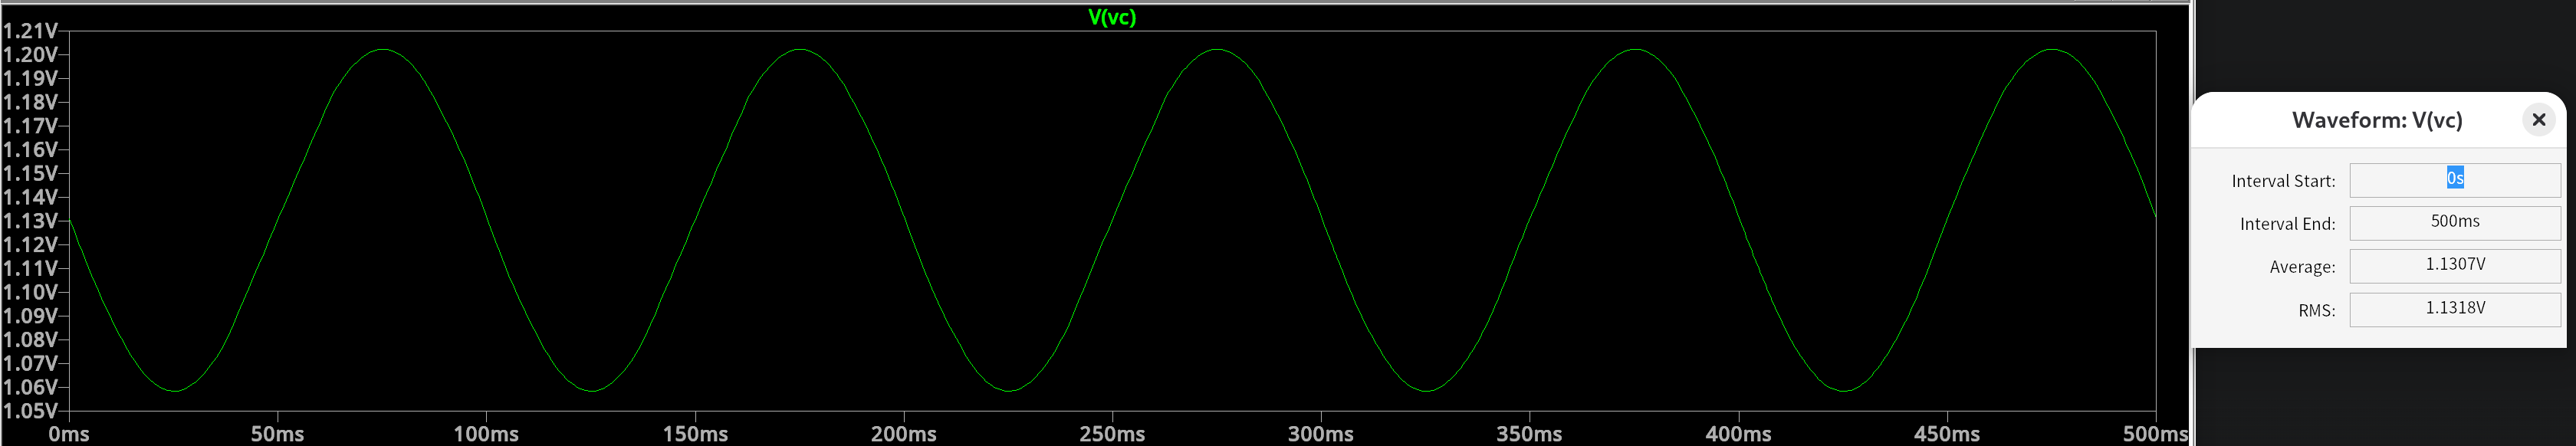</center>

Peak-to-peak is about $1.205 - 1.055 = 0.150$V = 150mV. Expected $2 \cdot 500\mu V \cdot 146 = 146$mV. Close enough.


__d)__ Calculate the values of $R_S$ and $R_L$ that each result in 1% attenuation from input to output ($V_s$ to $V_{out}$). Calculate each value separately (such that the combined attenuation would be around 2%). Verify your calculations by including the calculated values of $R_S$ and $R_L$ in your SPICE simulation. 

At the input, $R_S$ and $r_\pi$ form a voltage divider:

$$\frac{v_\pi}{v_s} = \frac{r_\pi}{R_S + r_\pi} = 0.99 \;\Rightarrow\; R_S = \frac{r_\pi}{99}.$$

At the output, $R_L$ forms a divider with the unloaded output resistance $R_{out} = R_C \| r_o$:

$$\frac{V_{out}(\text{loaded})}{V_{out}(\text{unloaded})} = \frac{R_L}{R_L + R_{out}} = 0.99 \;\Rightarrow\; R_L = 99 R_{out}.$$


In [2]:
import numpy as np

V_T=25.85e-3
I_S=1e-14
V_BE=0.69
beta=300
V_A=100
R_C=1e3

I_C=I_S*np.exp(V_BE/V_T)
g_m=I_C/V_T
r_pi=beta/g_m
r_o=V_A/I_C
R_out=(R_C*r_o)/(R_C+r_o)

R_S=r_pi/99
R_L=99*R_out

print(f'r_pi={r_pi} ohm')
print(f'R_out={R_out} ohm')
print(f'R_S for 1% input attenuation = {R_S} ohm')
print(f'R_L for 1% output attenuation = {R_L} ohm')

in_ratio=r_pi/(R_S+r_pi)
out_ratio=R_L/(R_L+R_out)
total=in_ratio*out_ratio
print(f'input ratio={in_ratio}')
print(f'output ratio={out_ratio}')
print(f'combined ratio={total}')
print(f'combined attenuation={(1-total)*100}%')


r_pi=1982.418055741269 ohm
R_out=962.3537851551324 ohm
R_S for 1% input attenuation = 20.024424805467362 ohm
R_L for 1% output attenuation = 95273.02473035811 ohm
input ratio=0.99
output ratio=0.99
combined ratio=0.9801
combined attenuation=1.9900000000000029%


Running `ce_loaded.cir` (same circuit with `Rs = 20.02`$\Omega$ and `Rl = 95.27`k$\Omega$ added):

<center>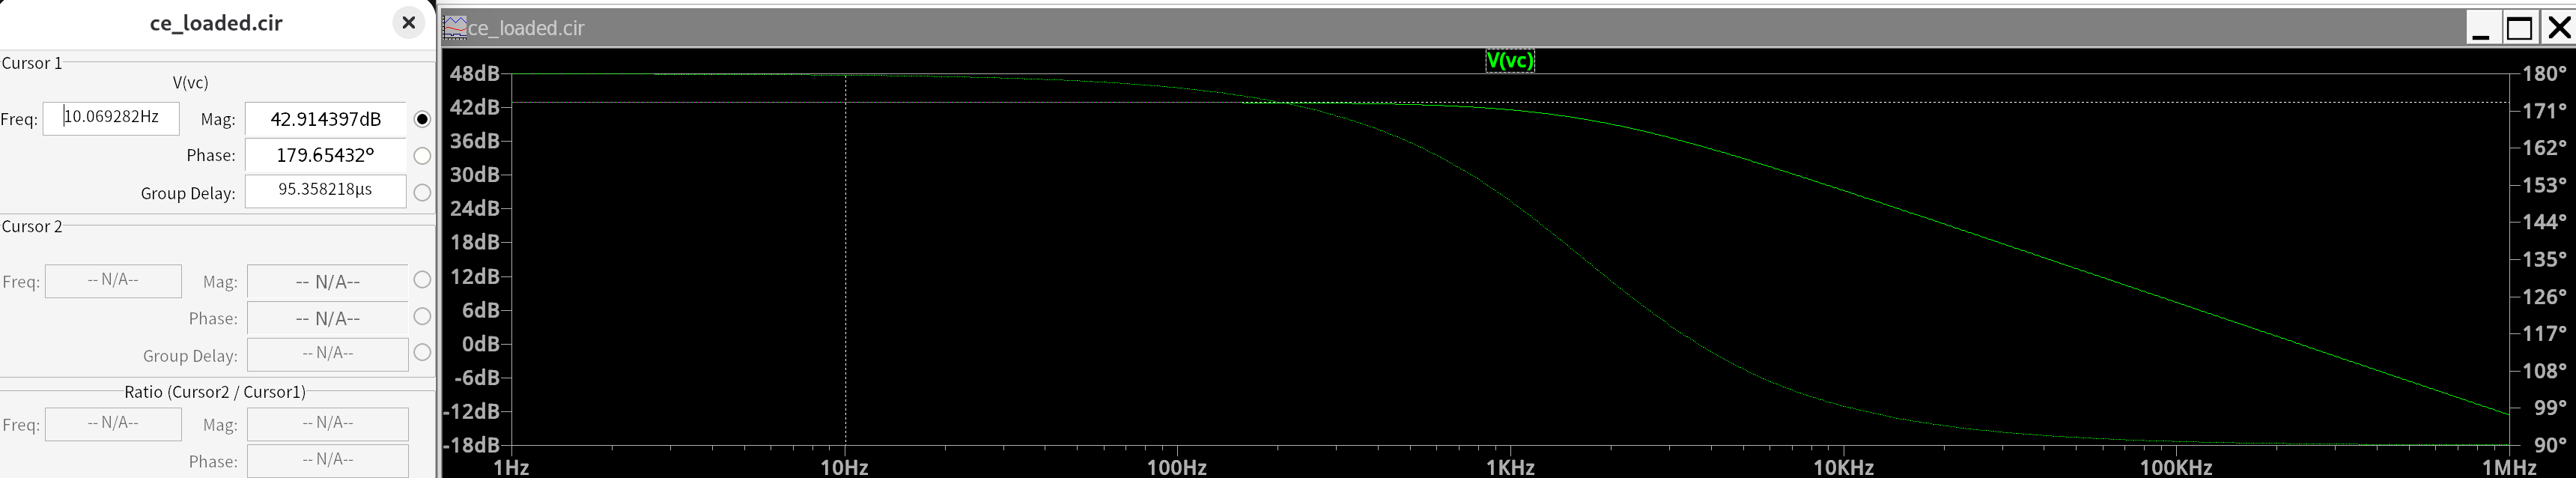</center>

DC plateau drops a tiny bit compared to part c (around 0.2dB, matching the expected $20\log_{10}(0.98) \approx -0.18$dB combined attenuation). So 2% total attenuation confirmed.
